**DAY SCALE OPTIMISATION**

The simplified day-scale visit problem falls into the class of classical Vehicle Routing Problems (VRP).

Here we use the powerful routing solver provided by Google OR-Tools:
https://developers.google.com/optimization/routing/vrp

As a reminder, we solve a simplified greedy problem: we select the 100 easiest stations to route (ignoring week-scale delivery frontier constraints) and compute the corresponding routes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ortools.constraint_solver import pywrapcp, routing_enums_pb2

Load data

In [2]:
dir = "data/"
#precomputed distance matrix
dist_km = np.load(dir + "distance_km.npy")
#sign colonne represent station need: +15 bikes or -15 bikes
stations_df = pd.read_csv(dir + "stations.csv")
stations_df.head()

,Unnamed: 0,station,sign,station_code,latitude,longitude
0,0,8012,15,8012,48.883475,2.326493
1,1,8020,15,8020,48.882164,2.319853
2,2,9004,15,9004,48.882943,2.346485
3,3,9005,15,9005,48.882633,2.344884
4,4,9037,15,9037,48.881266,2.328197


Missing visits leads to lost rewards. But reward should be balanced with operational cost 
= Prize collecting Routing Problem

In [3]:
visit_reward = 10
visit_time = 3
travel_speed = 1

Buffer penality for same sign station

In [4]:
# Truck should alternate +15 and -15 visits,  though they can also perform 
# implicit buffers visit. We model visit to a buffer through a constant penality

#their exist a buffer within 5 km:
buffer_radius = 5
sign = stations_df["sign"].values
# True if same sign
same_visit = sign[:, None] == sign[None, :]
buffer_penalty = same_visit*(2*buffer_radius/travel_speed + visit_time)

In [5]:
dist_matrix = dist_km.copy()
dist_matrix += visit_time
dist_matrix += buffer_penalty

In [6]:
def find_routs(n_vehicles=5):

    depot = 0

    n = dist_matrix.shape[0]

    manager = pywrapcp.RoutingIndexManager(
        n,
        n_vehicles,
        depot
    )

    routing = pywrapcp.RoutingModel(manager)

    # -------------------------
    # Distance callback
    # -------------------------

    def distance_callback(from_index, to_index):
        i = manager.IndexToNode(from_index)
        j = manager.IndexToNode(to_index)
        return int(dist_matrix[i, j])

    transit_callback = routing.RegisterTransitCallback(distance_callback)

    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback)

    # -------------------------
    # Max 20 nodes per truck
    # -------------------------

    def count_callback(from_index, to_index):
        return 1

    count_callback_index = routing.RegisterTransitCallback(count_callback)

    routing.AddDimension(
        count_callback_index,
        0,      # slack
        20,     # max nodes per vehicle
        True,   # start cumul to zero
        "Count"
    )

    # -------------------------
    # Optional visits (PCVRP)
    # -------------------------

    for node in range(1, n):  # depot excluded
        routing.AddDisjunction(
            [manager.NodeToIndex(node)],
            int(visit_reward)
        )

    # -------------------------
    # Search parameters
    # -------------------------

    search_parameters = pywrapcp.DefaultRoutingSearchParameters()

    search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    )

    search_parameters.local_search_metaheuristic = (
        routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    )

    search_parameters.time_limit.seconds = 30

    # -------------------------
    # Solve
    # -------------------------

    solution = routing.SolveWithParameters(search_parameters)

    if solution is None:
        return None

    # -------------------------
    # Extract routes
    # -------------------------

    routes = []

    for v in range(n_vehicles):

        index = routing.Start(v)
        route = []

        while not routing.IsEnd(index):
            route.append(manager.IndexToNode(index))
            index = solution.Value(routing.NextVar(index))

        route.append(manager.IndexToNode(index))
        routes.append(route)

    # dropped nodes
    dropped = []
    for node in range(n):
        if routing.IsStart(manager.NodeToIndex(node)) or routing.IsEnd(manager.NodeToIndex(node)):
            continue
        if solution.Value(routing.NextVar(manager.NodeToIndex(node))) == manager.NodeToIndex(node):
            dropped.append(node)

    return routes, dropped

In [7]:
routes, dropped = find_routs(n_vehicles = 5)

Now we can visualise results

In [8]:
from visualizer import print_routes, plot_routes

In [9]:
print_routes(routes, dropped)

Vehicle 00 : 0 -> 180 -> 2 -> 220 -> 89 -> 178 -> 108 -> 190 -> 102 -> 228 -> 112 -> 183 -> 109 -> 179 -> 111 -> 177 -> 110 -> 176 -> 117 -> 173 -> 0
Vehicle 01 : 0 -> 181 -> 9 -> 224 -> 106 -> 227 -> 10 -> 230 -> 95 -> 222 -> 11 -> 223 -> 100 -> 196 -> 24 -> 194 -> 33 -> 195 -> 50 -> 170 -> 0
Vehicle 02 : 0 -> 254 -> 65 -> 259 -> 71 -> 260 -> 72 -> 257 -> 66 -> 252 -> 69 -> 255 -> 67 -> 256 -> 68 -> 214 -> 73 -> 213 -> 5 -> 168 -> 0
Vehicle 03 : 0 -> 215 -> 1 -> 218 -> 7 -> 225 -> 123 -> 226 -> 122 -> 232 -> 119 -> 229 -> 25 -> 235 -> 31 -> 237 -> 32 -> 238 -> 12 -> 185 -> 0
Vehicle 04 : 0 -> 261 -> 79 -> 274 -> 78 -> 273 -> 77 -> 272 -> 76 -> 264 -> 75 -> 216 -> 4 -> 221 -> 8 -> 219 -> 6 -> 217 -> 3 -> 175 -> 0

Dropped : 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 26, 27, 28, 29, 30, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 70, 74, 80, 81, 82, 83, 84, 85, 86, 87, 88, 90, 91, 92, 93, 94, 96, 97, 98, 99, 10

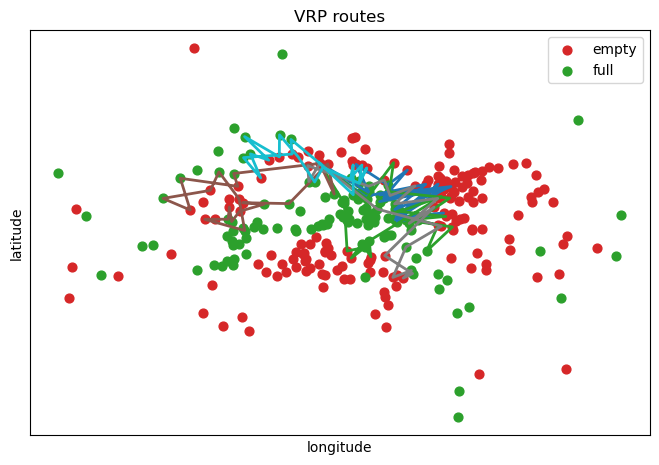

In [10]:
plot_routes(routes, dropped, stations_df)